# 4.0 Modelagem Preditiva e Avaliação

Nesta etapa, desenvolveremos e otimizaremos modelos de Machine Learning para buscar previsões do target `SalePrice`, utilizando: **Scikit-Learn**, **XGBoost** e **LightGBM**.

---

### **(5.0) Modelos Lineares**

* Desenvolvimento e avaliação de modelos lineares usando o **dataframe otimizado**, com `11 colunas totais [10 features + 1 target]`

* Desenvolvimento de 4 modelos: **LinearRegression, Ridge, Lasso, ElasticNet**

* Comparação de suas métricas ( MAE, RMSE, R²)

* Uso de divisão treino/validação e métricas revertidas da **escala logarítmica** para dólares americanos, garantindo avaliação direta no contexto de negócio.

---


__________________________________________________________________________________________

In [16]:
# Importando bibliotecas
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
import matplotlib.ticker as ticker

# Modelos de alta performance
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Configuração de estilo para os gráficos 
sns.set_theme(style="whitegrid")

# Ignorar avisos 
import warnings
warnings.filterwarnings('ignore')

# Definindo o diretório 
caminho = os.getcwd()

# Carregando os datasets
df_treino_linear = pd.read_csv(os.path.join(caminho, "csv_gerados", "df_treino_linear.csv"))
df_teste_linear = pd.read_csv(os.path.join(caminho, "csv_gerados", "df_teste_linear.csv"))


## *Função para avaliar um modelo com base nas suas métricas*

* `MAE` = Erro absoluto médio

* `RMSE` = Erro médio ao quadrado

* `R²` = Coeficiente de Determinação

O modelo será feito com base em **X_train,  y_train, X_val, y_val, modelo**

#### Protocolo de Avaliação

O treinamento é realizado exclusivamente nos conjuntos de desenvolvimento (**`X_train`** e **`y_train`**). Para diagnosticar problemas de ajuste, a validação segue dois momentos:

1. **Avaliação em Treino:** Mede a aderência do algoritmo aos dados conhecidos para verificar sua capacidade de aprendizado.
2. **Avaliação em Validação:** Testa o modelo em dados não vistos (**`X_val`** e **`y_val`**), simulando o cenário real de predição.

---

#### Métricas Calculadas

* **MAE Treino:** Erro médio absoluto cometido sobre as amostras de treino (US$).
* **MAE Validação:** Erro médio absoluto cometido sobre as amostras de validação (US$).
* **Gap de MAE ($\Delta\text{MAE}$):** Diferença absoluta entre o MAE de validação e o de treino, evidenciando o nível de *overfitting* em dólares.
* **RMSE Treino:** Raiz do erro quadrático médio em treino, monitorando a penalização a erros extremos na base conhecida (US$).
* **RMSE Validação:** Raiz do erro quadrático médio em validação, avaliando a robustez do modelo contra grandes desvios em dados novos (US$).
* **Gap de RMSE ($\Delta\text{RMSE}$):** Diferença entre o RMSE de validação e o de treino, medindo a sensibilidade a *outliers* fora da amostra (US$).
* **$R^2$ Treino:** Coeficiente de determinação na base de treino, indicando a proporção da variância capturada pelo algoritmo.
* **$R^2$ Validação:** Coeficiente de determinação na base de validação, aferindo o poder preditivo real da solução.
* **Gap de $R^2$ ($\Delta R^2$):** Queda de explicação de variância do treino para a validação (adimensional), indicando perda de capacidade de generalização.

In [17]:
def avaliar_modelo(modelo, X_train, y_train, X_val, y_val, nome_modelo):
    """Treina o modelo, reverte o log1p e calcula as métricas reais em dólares."""
    # Treinando o modelo
    modelo.fit(X_train, y_train)
    
    # Fazendo previsões na escala log
    pred_train_log = modelo.predict(X_train)
    pred_val_log = modelo.predict(X_val)
    
    # Revertendo o log1p (np.expm1) para calcular o erro real em US$
    y_train_real = np.expm1(y_train)
    y_val_real = np.expm1(y_val)
    pred_train_real = np.expm1(pred_train_log)
    pred_val_real = np.expm1(pred_val_log)
    
    # Calculando métricas na escala original (US$)
    mae_train = mean_absolute_error(y_train_real, pred_train_real)
    mae_val = mean_absolute_error(y_val_real, pred_val_real)
    
    rmse_train = np.sqrt(mean_squared_error(y_train_real, pred_train_real))
    rmse_val = np.sqrt(mean_squared_error(y_val_real, pred_val_real))
    
    r2_train = r2_score(y_train_real, pred_train_real)
    r2_val = r2_score(y_val_real, pred_val_real)
    
    # Exibição estruturada dos resultados
    print(f"==================== {nome_modelo} ====================")
    print(f"MAE Treino:      ${mae_train:,.2f}")
    print(f"MAE Validação:   ${mae_val:,.2f}  (Gap: ${mae_val - mae_train:,.2f})")
    print(f"RMSE Treino:     ${rmse_train:,.2f}")
    print(f"RMSE Validação:  ${rmse_val:,.2f}  (Gap: ${rmse_val - rmse_train:,.2f})")
    print(f"R² Treino:       {r2_train:.4f}")
    print(f"R² Validação:    {r2_val:.4f}  (Gap: {r2_train - r2_val:.4f})\n")
    
    return modelo

__________________________________________________________________________________________

### (5.1) **Analise dos principais modelos lineares**

Os modelos lineares buscam mapear uma relação linear entre as *features* usadas na prediação e o Target (`SalePrice`), ajustando um hiperplano no espaço vetorial dos dados.

Modelos lineares são altamente sensíveis à **multicolinearidade** (correlação excessiva entre preditores) e à **alta dimensionalidade**. Por isso é *Crucial* trabalhar datasets enxutos, destacando as features mais importantes e buscar possívies *reduções* de dimensionalidade

Modelos lineares tendem a causar erros de **underfitting**

__________________________________________________________________-


(1) **Linear Regression:** Ajusta os coeficientes através do método dos Mínimos Quadrados, sem nenhum tipo de restrição ou penalidade.

(2) **Ridge (Regularização $L_2$):** Adiciona uma penalidade proporcional ao **quadrado** dos coeficientes. Reduz o valor das features menos relevantes sem zerá-los, amenizando o impacto da multicolinearidade.

(3) **Lasso (Regularização $L_1$):** Adiciona uma penalidade proporcional ao **módulo** dos coeficientes. Atua como seleção automática de variáveis, forçando os coeficientes de *features* irrelevantes a caírem para exatamente zero.

(4) **ElasticNet:** Híbrido entre $L_1$ e $L_2$. Combina a capacidade do Lasso de zerar variáveis dispensáveis com a estabilidade do Ridge para lidar com grupos de variáveis correlacionadas.

In [18]:

X_linear = df_treino_linear.drop(columns=['SalePrice'])
y_linear = df_treino_linear['SalePrice']

#  Divisão em Treino e Validação (80/20) para o Dataset Linear
X_train_lin, X_val_lin, y_train_lin, y_val_lin = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42
)

# modelos lineares
lin_reg = LinearRegression()
ridge_reg = Ridge(alpha=1.0, random_state=42) # Ridge penaliza coeficientes grandes (L2)
lasso_reg = Lasso(alpha=0.001, random_state=42) # Lasso consegue zerar coeficientes (L1)
elastic_net = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42) # Mistura L1 e L2

# Avaliando os Modelos Lineares 
print("================ AVALIAÇÃO MODELOS LINEARES ================\n")
avaliar_modelo(lin_reg, X_train_lin, y_train_lin, X_val_lin, y_val_lin, "Regressão Linear Tradicional")
avaliar_modelo(ridge_reg, X_train_lin, y_train_lin, X_val_lin, y_val_lin, "Regressão Ridge")
avaliar_modelo(lasso_reg, X_train_lin, y_train_lin, X_val_lin, y_val_lin, "Regressão Lasso")
avaliar_modelo(elastic_net, X_train_lin, y_train_lin, X_val_lin, y_val_lin, "Regressão ElasticNet")

================ AVALIAÇÃO MODELOS LINEARES ================

==================== Regressão Linear Tradicional ====================
MAE Treino:      $18,319.11
MAE Validação:   $19,327.22  (Gap: $1,008.11)
RMSE Treino:     $27,568.07
RMSE Validação:  $26,097.57  (Gap: $-1,470.50)
R² Treino:       0.8833
R² Validação:    0.8767  (Gap: 0.0066)

==================== Regressão Ridge ====================
MAE Treino:      $18,315.62
MAE Validação:   $19,335.98  (Gap: $1,020.36)
RMSE Treino:     $27,600.88
RMSE Validação:  $26,123.49  (Gap: $-1,477.38)
R² Treino:       0.8830
R² Validação:    0.8765  (Gap: 0.0066)

==================== Regressão Lasso ====================
MAE Treino:      $18,295.63
MAE Validação:   $19,325.06  (Gap: $1,029.43)
RMSE Treino:     $27,710.52
RMSE Validação:  $26,168.02  (Gap: $-1,542.50)
R² Treino:       0.8821
R² Validação:    0.8760  (Gap: 0.0061)

==================== Regressão ElasticNet ====================
MAE Treino:      $18,302.52
MAE Validação:   $19,

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.001
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


> ### **Desempenho dos Modelos Lineares**
>
> | Modelo | MAE Treino | MAE Validação | Gap (MAE) | RMSE Validação | $R^2$ Validação |
> | :--- | :---: | :---: | :---: | :---: | :---: |
> | **Regressão Linear Tradicional** | \$18,319.11 | \$19,327.22 | **\$1,008.11** | \$26,097.57 | **0.8767** |
> | **Regressão Ridge ($L_2$)** | \$18,315.62 | \$19,335.98 | \$1,020.36 | \$26,123.49 | 0.8765 |
> | **Regressão Lasso ($L_1$)** | \$18,295.63 | \$19,325.06 | \$1,029.43 | \$26,168.02 | 0.8760 |
> | **ElasticNet ($L_1 + L_2$)** | \$18,302.52 | \$19,325.00 | \$1,022.48 | \$26,139.40 | 0.8763 |
>
> ---
>
> **Principais Diagnósticos:**
>
> 1. **Robustez e Estabilidade dos Modelos Lineares:**
>   Veja que tanto para o modelo tradicional como para os modelos com regularizações (L1,L2,ElasticNET) os **resultados apresentam grande proximidade e coerência**. Desse modo, `mostra a robustez e estabilidade das features e do ajuste linear`.
>
> 2. **Validação do Trabalho de Pré-processamento:**
>    O fato de os métodos de contração de coeficientes (Ridge/Lasso) não terem causado alterações bruscas confirma que as **10 features para o modelo linear** selecionadas `não contêm ruído`, esparsidade excessiva ou multicolinearidade prejudicial.
>
> 3. **Generalização Notável (Baixo Gap de MAE):**
>    O gap entre o erro de treino e validação ficou contido em torno de apenas **\$1,000.00** (~5% do erro total). Essa proximidade evidencia que os modelos lineares não decoraram os dados de treino, apresentando excelente capacidade de generalização com um $R^2$ consistente de **~0.876** em dados não vistos.

### **(5.2) Coeficientes e Intercept para os modelos lineares**

* Verificando os `Coeficientes` para as 10 features e seu Intercept

In [19]:
# Obter os coeficientes e constantes dos modelos lineares
features = df_treino_linear.drop(columns=['SalePrice']).columns

# Dataframe
coeficientes = pd.DataFrame({
    "Linear": lin_reg.coef_,
    "Ridge": ridge_reg.coef_,
    "Lasso": lasso_reg.coef_,
    "ElasticNet": elastic_net.coef_
}, index=features)

# Adcionando o intercept 
coeficientes.loc['Intercept'] = [
    lin_reg.intercept_,
    ridge_reg.intercept_,
    lasso_reg.intercept_,
    elastic_net.intercept_
]

display(coeficientes.round(5))


,Linear,Ridge,Lasso,ElasticNet
Luxury_Score,0.21986,0.21893,0.21528,0.21702
GrLivArea,0.31579,0.31123,0.30730,0.30882
GarageCars,0.05949,0.06008,0.05983,0.05996
TotalBsmtSF,0.00014,0.00014,0.00015,0.00014
TotalBaths,0.05915,0.05992,0.05940,0.05971
Idade_Casa,-0.00102,-0.00101,-0.00103,-0.00102
Idade_Reforma,-0.00146,-0.00148,-0.00153,-0.00151
MasVnrArea,-0.00039,-0.00032,-0.00000,-0.00006
Fireplaces,0.03019,0.03093,0.03070,0.03085
LotFrontage,0.11383,0.11322,0.10441,0.10878


* Impactos dos coeficientes no `SalesPrice` para a **Regressão Linear Simples**:

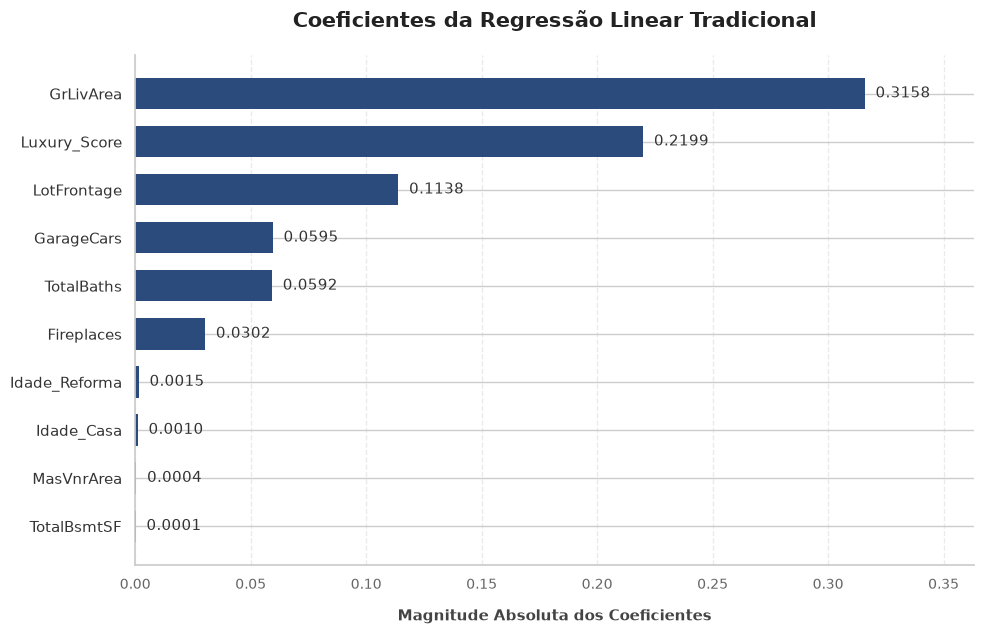

In [20]:
# Extração e ordenação dos coeficientes em módulo (valor absoluto)
features_linear = df_treino_linear.drop(columns=['SalePrice']).columns
importancia = pd.Series(np.abs(lin_reg.coef_), index=features_linear).sort_values(ascending=True)

# Configuração do Canvas
fig, ax = plt.subplots(figsize=(10, 6.5))

#Plotagem das Barras Horizontais
bars = ax.barh(importancia.index, importancia.values, color='#2A4B7C', edgecolor='none', height=0.65)

# Limpeza Visual (Removendo bordas desnecessárias)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Grid vertical discreto atrás das barras
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#DDDDDD')
ax.set_axisbelow(True) 

# 5Títulos e Eixos
ax.set_xlabel('Magnitude Absoluta dos Coeficientes', fontsize=11, fontweight='bold', color='#444444', labelpad=12)
ax.set_title('Coeficientes da Regressão Linear Tradicional', fontsize=15, fontweight='bold', color='#222222', pad=20)

# 6. Rótulos Dinâmicos nas Barras
max_val = importancia.max()
offset = max_val * 0.015 # Deslocamento dinâmico para não colar o texto na barra

for bar in bars:
    width = bar.get_width()
    ax.text(width + offset, 
            bar.get_y() + bar.get_height()/2, 
            f'{width:.4f}', 
            va='center', 
            ha='left', 
            fontsize=10.5, 
            color='#333333',
            fontweight='500')

# Expande o eixo X em 15% para garantir que os números não fiquem cortados
ax.set_xlim(0, max_val * 1.15)

# Estilizando os ticks (rótulos das features)
ax.tick_params(axis='y', labelsize=11, colors='#333333')
ax.tick_params(axis='x', labelsize=10, colors='#666666')

plt.tight_layout()
plt.show()

> ### Análise dos Coeficientes — Regressão Linear Tradicional
> 
> ---
> 
> #### Tabela de Coeficientes
> 
> | Variável | Magnitude Absoluta | Impacto Relativo |
> | :--- | :---: | :--- |
> | **`GrLivArea`** | `0.3158` | Dominante (Maior sensibilidade no modelo) |
> | **`Luxury_Score`** | `0.2199` | Muito Alto (Componente de valor agregado) |
> | **`LotFrontage`** | `0.1138` | Moderado a Alto (Dimensão de terreno) |
> | **`GarageCars`** | `0.0595` | Moderado (Capacidade de veículos) |
> | **`TotalBaths`** | `0.0592` | Moderado (Infraestrutura de banheiros) |
> | **`Fireplaces`** | `0.0302` | Baixo (Atributo secundário de conforto) |
> | **`Idade_Reforma`** | `0.0015` | Marginal / Residual |
> | **`Idade_Casa`** | `0.0010` | Marginal / Residual |
> | **`MasVnrArea`** | `0.0004` | Desprezível no modelo linear |
> | **`TotalBsmtSF`** | `0.0001` | Desprezível no modelo linear |
> 
> ---
> 
> #### Principais Conclusões
> 
> * **Features Principais para o Preço:** A área útil acima do solo (`GrLivArea`) e a métrica composta de acabamento (`Luxury_Score`) concentram a maior parte do poder explicativo linear, com coeficientes de **0.3158** e **0.2199**, respectivamente.

> * **Comportamento das Dimensões Físicas:** Características estruturais como frente do lote (`LotFrontage`), vagas de garagem (`GarageCars`) e total de banheiros (`TotalBaths`) atuam como modificadores intermediários.

> * **Limitação da Escala Linear:** Variáveis contínuas com magnitudes muito baixas (como `TotalBsmtSF` e `Idade_Casa`) sofrem distorção pela escala dos dados brutos ou por multicolinearidade com `GrLivArea`, justificando a necessidade de modelos baseados em árvores para capturar relações não lineares e efeitos de interação.

### **(5.3) Análise Gráfica da Regressão Linear**

Os gráficos abaixo avaliam a qualidade do modelo de **Regressão Linear Tradicional** na base de validação, verificando:

1. **Dispersão (Previsto vs Real)** — O quão próximo da reta perfeita o modelo se encontra
2. **Distribuição dos Resíduos** — Os erros seguem distribuição normal?
4. **QQ Plot** — Confirmação visual da normalidade dos resíduos

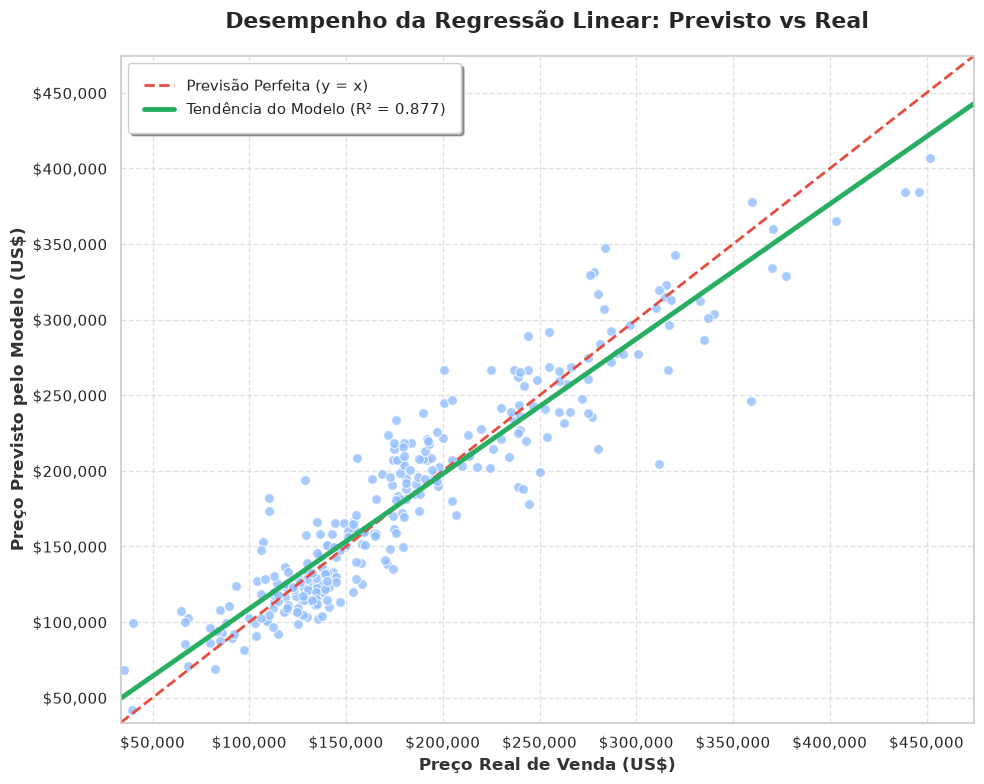

Inclinação (Slope): 0.8920 )
Intercept: $19,669.29


In [ ]:
# Previsões do modelo linear na escala real (US$)
pred_val_log = lin_reg.predict(X_val_lin)
pred_val_real = np.expm1(pred_val_log)
y_val_real = np.expm1(y_val_lin.values)

# =========================================================
# GRÁFICO DE DISPERSÃO: Previsto vs Real 
# =========================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter Plot: Pontos com bordas brancas evitam a aparência de "borrão" em áreas densas
ax.scatter(y_val_real, pred_val_real, alpha=0.8, s=50, color="#91BDFF", edgecolors='white', linewidth=0.8)

# Definindo limites dinâmicos para o gráfico com base nos dados
min_val = min(y_val_real.min(), pred_val_real.min()) * 0.95
max_val = max(y_val_real.max(), pred_val_real.max()) * 1.05
lims = [min_val, max_val]

# Reta de Previsão Perfeita (y = x) - Vermelho suave
ax.plot(lims, lims, '--', color='#E74C3C', linewidth=2, label='Previsão Perfeita (y = x)')

# Reta de Regressão (Tendência real do modelo) - Verde esmeralda
slope, intercept, r_value, _, _ = stats.linregress(y_val_real, pred_val_real)
x_line = np.linspace(lims[0], lims[1], 100)
ax.plot(x_line, slope * x_line + intercept, color='#27AE60', linewidth=3.5,
         label=f'Tendência do Modelo (R² = {r_value**2:.3f})')

# Formatação Profissional dos Eixos (Moeda)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

# Textos, Títulos e Estilização de Fontes
ax.set_xlabel('Preço Real de Venda (US$)', fontsize=12, fontweight='bold', color='#333333')
ax.set_ylabel('Preço Previsto pelo Modelo (US$)', fontsize=12, fontweight='bold', color='#333333')
ax.set_title('Desempenho da Regressão Linear: Previsto vs Real', fontsize=16, fontweight='bold', pad=20)

# Customização do Grid e Legenda
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11, loc='upper left', frameon=True, shadow=True, borderpad=1)

# Aplicando limites
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

# Impressão simplificada das métricas da reta
print(f"Inclinação (Slope): {slope:.4f} )")
print(f"Intercept: ${intercept:,.2f}")

> ### Análise do Gráfico de Dispersão — Desempenho da Regressão Linear
> 
> ---
> 
> O gráfico ilustra a aderência das estimativas da Regressão Linear em relação aos valores reais de venda, comparando a reta ajustada pelo modelo (**verde**) com a linha de referência ideal (**vermelha tracejada, $y = x$**).
> 
> ---
> 
> #### Principais Observações Técnicas
> 
> * **Aderência Global Satisfatória ($R^2 = 0.877$):** A reta de tendência do modelo acompanha de perto a bissetriz ideal (y=x), indicando que a aproximação linear captura com consistência a dinâmica central de formação dos preços.
>
> * **Concentração no Segmento Intermediário:** A densidade de pontos entre **US$ 100.000** e **US$ 250.000** é compacta e alinhada à diagonal, faixa onde o modelo atinge seu menor nível de erro e maior estabilidade, região essa em que acontece o maior número de vendas.
>
> * **Subestimação em Faixas Extremas (Imóveis de Luxo):** A partir de **US$ 300.000**, a reta verde começa a descolar abaixo da linha vermelha, mostrando que o modelo tende a subestimar sistematicamente as propriedades de valor mais elevado, indicando um defeito desse modelo
>
> * **Superestimação em Faixas Muito Baixas:** Para casas abaixo de **US$ 100.000**, nota-se o comportamento inverso: a linha verde fica ligeiramente acima da referência, projetando valores superiores ao mercado real.

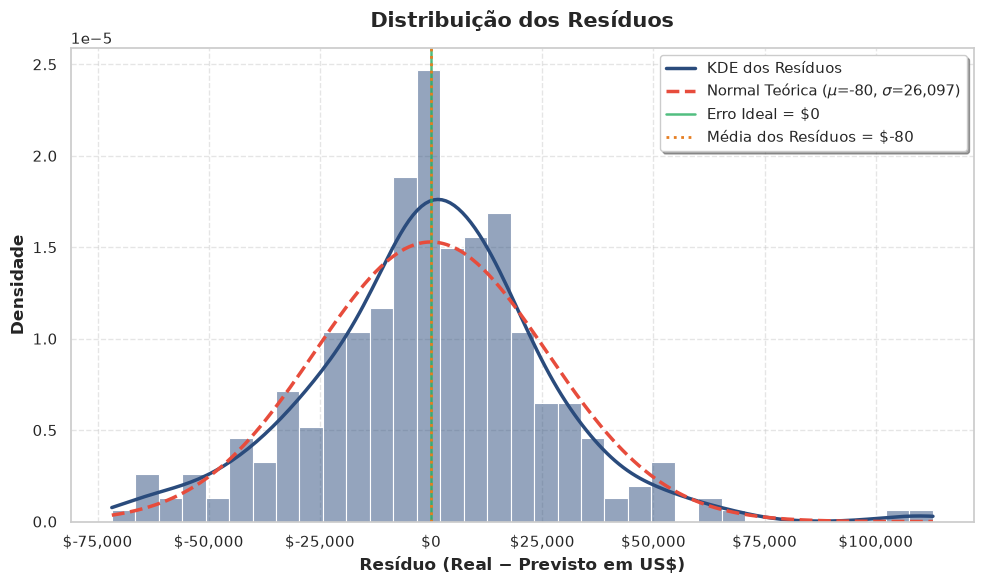

Média dos resíduos:     $-80.42
Desvio padrão:          $26,097.45
Assimetria (Skewness):   0.2763
Curtose (Kurtosis):      1.7954


In [22]:
# =========================================================
# DISTRIBUIÇÃO DOS RESÍDUOS COM CURVA NORMAL TEÓRICA
# =========================================================
# Resíduos na escala real (US$)
residuos = y_val_real - pred_val_real
media_res = residuos.mean()
std_res = residuos.std()

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Histograma com KDE empírica (Distribuição Real dos Dados)
sns.histplot(
    residuos,
    kde=True,
    bins=35,
    stat='density',
    color='#2A4B7C',
    edgecolor='white',
    linewidth=0.8,
    line_kws={'linewidth': 2.5, 'label': 'KDE dos Resíduos'},
    ax=ax,
)

# 2. Curva Normal Teórica N(μ, σ²) sobreposta
x_axis = np.linspace(residuos.min(), residuos.max(), 300)
pdf_normal = stats.norm.pdf(x_axis, loc=media_res, scale=std_res)
ax.plot(
    x_axis,
    pdf_normal,
    color='#E74C3C',
    linestyle='--',
    linewidth=2.5,
    label=f'Normal Teórica ($\mu$={media_res:,.0f}, $\sigma$={std_res:,.0f})',
)

# 3. Linhas de Referência (Erro Zero e Média)
ax.axvline(
    0,
    color='#27AE60',
    linestyle='-',
    linewidth=1.8,
    alpha=0.8,
    label='Erro Ideal = $0',
)
ax.axvline(
    media_res,
    color='#E67E22',
    linestyle=':',
    linewidth=2,
    label=f'Média dos Resíduos = ${media_res:,.0f}',
)

# Formatação dos Eixos
formatter = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.xaxis.set_major_formatter(formatter)

# Estilização
ax.set_title(
    'Distribuição dos Resíduos',
    fontsize=15,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Resíduo (Real − Previsto em US$)', fontsize=12, fontweight='bold')
ax.set_ylabel('Densidade', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10.5, loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# Diagnóstico Estatístico da Distribuição
print(f'Média dos resíduos:     ${media_res:,.2f}')
print(f'Desvio padrão:          ${std_res:,.2f}')
print(f'Assimetria (Skewness):   {stats.skew(residuos):.4f}')
print(f'Curtose (Kurtosis):      {stats.kurtosis(residuos):.4f}')

> ### Análise da Distribuição dos Resíduos
> 
> ---
> 
> O gráfico avalia o comportamento estatístico dos erros residuais ($y - \hat{y}$) em dólares, confrontando a densidade empírica observada (**KDE**, em azul escuro) com a distribuição Gaussiana esperada (**Normal Teórica**, em vermelho tracejado).
> 
> ---
> 
> #### Parâmetros do Ajuste
> 
> | Parâmetro | Valor | Interpretação |
> | :--- | :---: | :--- |
> | **Média dos Resíduos ($\mu$)** | `-$80` | Praticamente nula (Alinhada ao Erro Ideal de `$0`) |
> | **Desvio Padrão ($\sigma$)** | `$26,097` | Dispersão típica do erro em torno da média |
> | **Intervalo Central ($\pm 1\sigma$)** | `[-$26,177 ; +$26,017]` | Faixa que concentra ~68% das previsões do modelo |
> 
> ---
> 
> #### Principais Conclusões Técnicas
> 
> * **Ausência de Viés Sistemático:** A média dos resíduos de **-$80** sobrepõe-se perfeitamente à linha de erro zero (**$0**), confirmando que o modelo é globalmente não enviesado (não tende a superfaturar nem a subfaturar os imóveis em média).
>
> * **Leptocurtose (Pico Elevado no Centro):** O pico do KDE é visivelmente mais acentuado e estreito que o topo da normal teórica, indicando uma concentração de acertos próximos de zero maior do que uma distribuição normal pura prevê.
>
> * **Simetria Predominante:** A distribuição apresenta formato equilibrado entre as faixas de **-$50.000** e **+$50.000**, demonstrando estabilidade na variância da maior parte da amostra.
>
> * **Presença de Cauda Longa à Direita (Outliers Positivos):** Observam-se resíduos residuais isolados que ultrapassam **+$100.000**, apontando casos específicos em que o modelo subestimou expressivamente imóveis com características atípicas ou de altíssimo padrão.

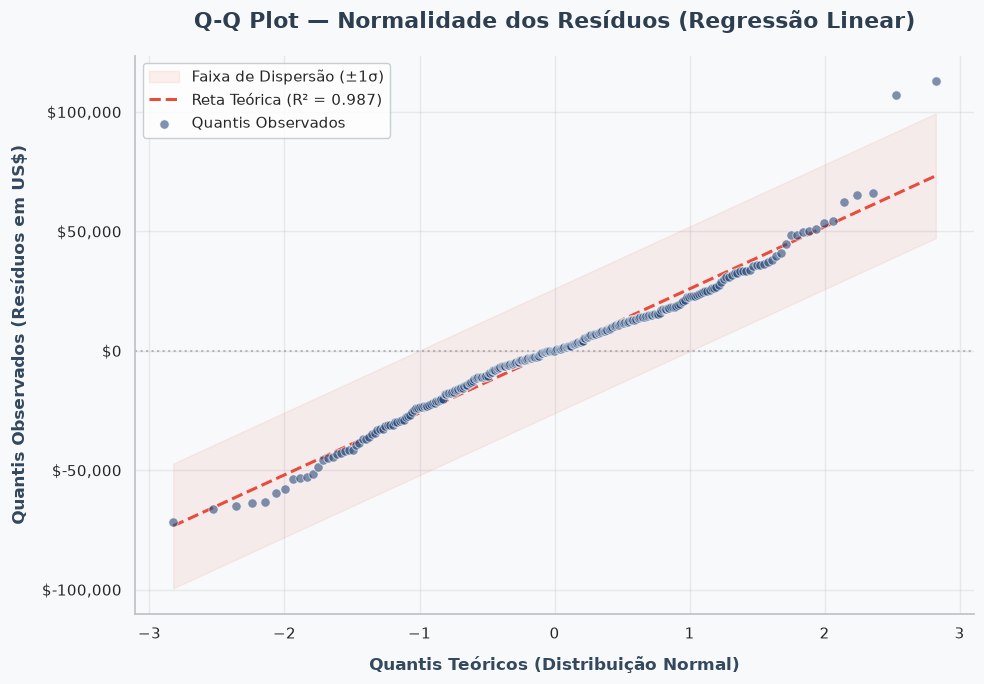

In [23]:
## =========================================================
# QQ PLOT 
# =========================================================
# 
#  Cálculo do desvio padrão necessário para a área de preenchimento (caso não esteja no escopo)
std_res = np.std(residuos)

# Configuração da Figura com fundo sutil para estilo corporativo
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

# stats.probplot extrai os dados matemáticos da distribuição sem plotar automaticamente
(osm, osr), (slope, intercept, r_value) = stats.probplot(residuos, dist="norm")

# Faixa de confiança visual (±1 desvio padrão em relação à reta teórica)
x_fill = np.linspace(osm[0], osm[-1], 200)
y_fit = slope * x_fill + intercept
ax.fill_between(x_fill, y_fit - std_res, y_fit + std_res, 
                alpha=0.08, color='#E74C3C', label='Faixa de Dispersão (±1σ)', zorder=1)

# Reta teórica (distribuição normal perfeita)
x_line = np.array([osm[0], osm[-1]])
ax.plot(x_line, slope * x_line + intercept, '--', color='#E74C3C', linewidth=2.2,
        label=f'Reta Teórica (R² = {r_value:.3f})', zorder=2)

# Linha de zero absoluto para ancorar visualmente o centro geométrico dos erros
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, zorder=2)

# Pontos da amostra (transparência ajustada para mostrar densidade onde há sobreposição)
ax.scatter(osm, osr, s=45, color='#2A4B7C', edgecolors='white', linewidth=0.7, 
           alpha=0.6, label='Quantis Observados', zorder=3)

# Formatação monetária limpa do eixo Y
fmt_moeda = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.yaxis.set_major_formatter(fmt_moeda)

# Estilização Minimalista
ax.set_title('Q-Q Plot — Normalidade dos Resíduos (Regressão Linear)', 
             fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
ax.set_xlabel('Quantis Teóricos (Distribuição Normal)', fontsize=12, fontweight='bold', color='#34495E', labelpad=10)
ax.set_ylabel('Quantis Observados (Resíduos em US$)', fontsize=12, fontweight='bold', color='#34495E', labelpad=10)

# Limpeza visual (remoção das bordas superior e direita - chart junk)
ax.grid(True, linestyle='-', alpha=0.3, color='#BDC3C7')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#BDC3C7')
ax.spines['bottom'].set_color('#BDC3C7')

# Legenda sem sombra para um visual mais moderno e "flat"
ax.legend(fontsize=11, loc='upper left', frameon=True, edgecolor='#BDC3C7', facecolor='white')

plt.tight_layout()
plt.show()

> ### Análise do Q-Q Plot — Normalidade dos Resíduos
> 
> ---
> 
> O gráfico avalia a hipótese de normalidade dos erros comparando os quantis empíricos dos resíduos (**pontos azuis**) contra a reta teórica esperada sob uma distribuição Gaussiana/Normal (**linha tracejada vermelha**), contida na faixa de dispersão de $\pm 1\sigma$.
> 
> ---
> 
> #### Métricas do Ajuste
> 
> | Parâmetro | Valor | Diagnóstico |
> | :--- | :---: | :--- |
> | **Correlação Teórica ($R^2$)** | `0.987` | Altíssima aderência global à normalidade |
> | **Região Central (Quantis $[-1.5, +1.5]$)** | Linear | Erros medianos com distribuição gaussiana quase perfeita |
> | **Faixa de Incerteza** | $\pm 1\sigma$ | Quase a totalidade da amostra contida no intervalo |
> 
> ---
> 
> #### Principais Conclusões Técnicas
> 
> * **Consistência Central Sólida ($R^2 = 0.987$):** No intervalo entre quantis teóricos $-1.5$ e $+1.5$ (resíduos entre $-\$40.000$ e $+\$40.000$), os pontos seguem rigidamente a diagonal, nesse caso, mostrando que a eficácia da regressão linear

> * **Cauda Pesada Superior (Outliers de Luxo):** A partir do quantil teórico $+2.0$, observa-se um descolamento expressivo para cima, com dois imóveis ultrapassando $+\$100.000$ de resíduo (inclusive furando a banda de $+1\sigma$). O modelo subestima sistematicamente essas residências mais caras, como já visto anteriormente.

> * **Comportamento na Cauda Inferior:** Para os quantis teóricos abaixo de $-2.0$, os resíduos se acomodam em um patamar próximo a $-\$60.000$, mantendo-se dentro da faixa de dispersão sem quedas extrema.


> * **Veredito para o Relatório:** A Regressão Linear apresenta excelente comportamento estatístico médio ($R^2 = 0.987$ nos quantis).